In [41]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import math
import seaborn as sns
from scipy.stats import boxcox, normaltest, skew

In [49]:
df = pd.read_csv("hf://datasets/maharshipandya/spotify-tracks-dataset/dataset.csv", index_col = 0)

## Data Visualization

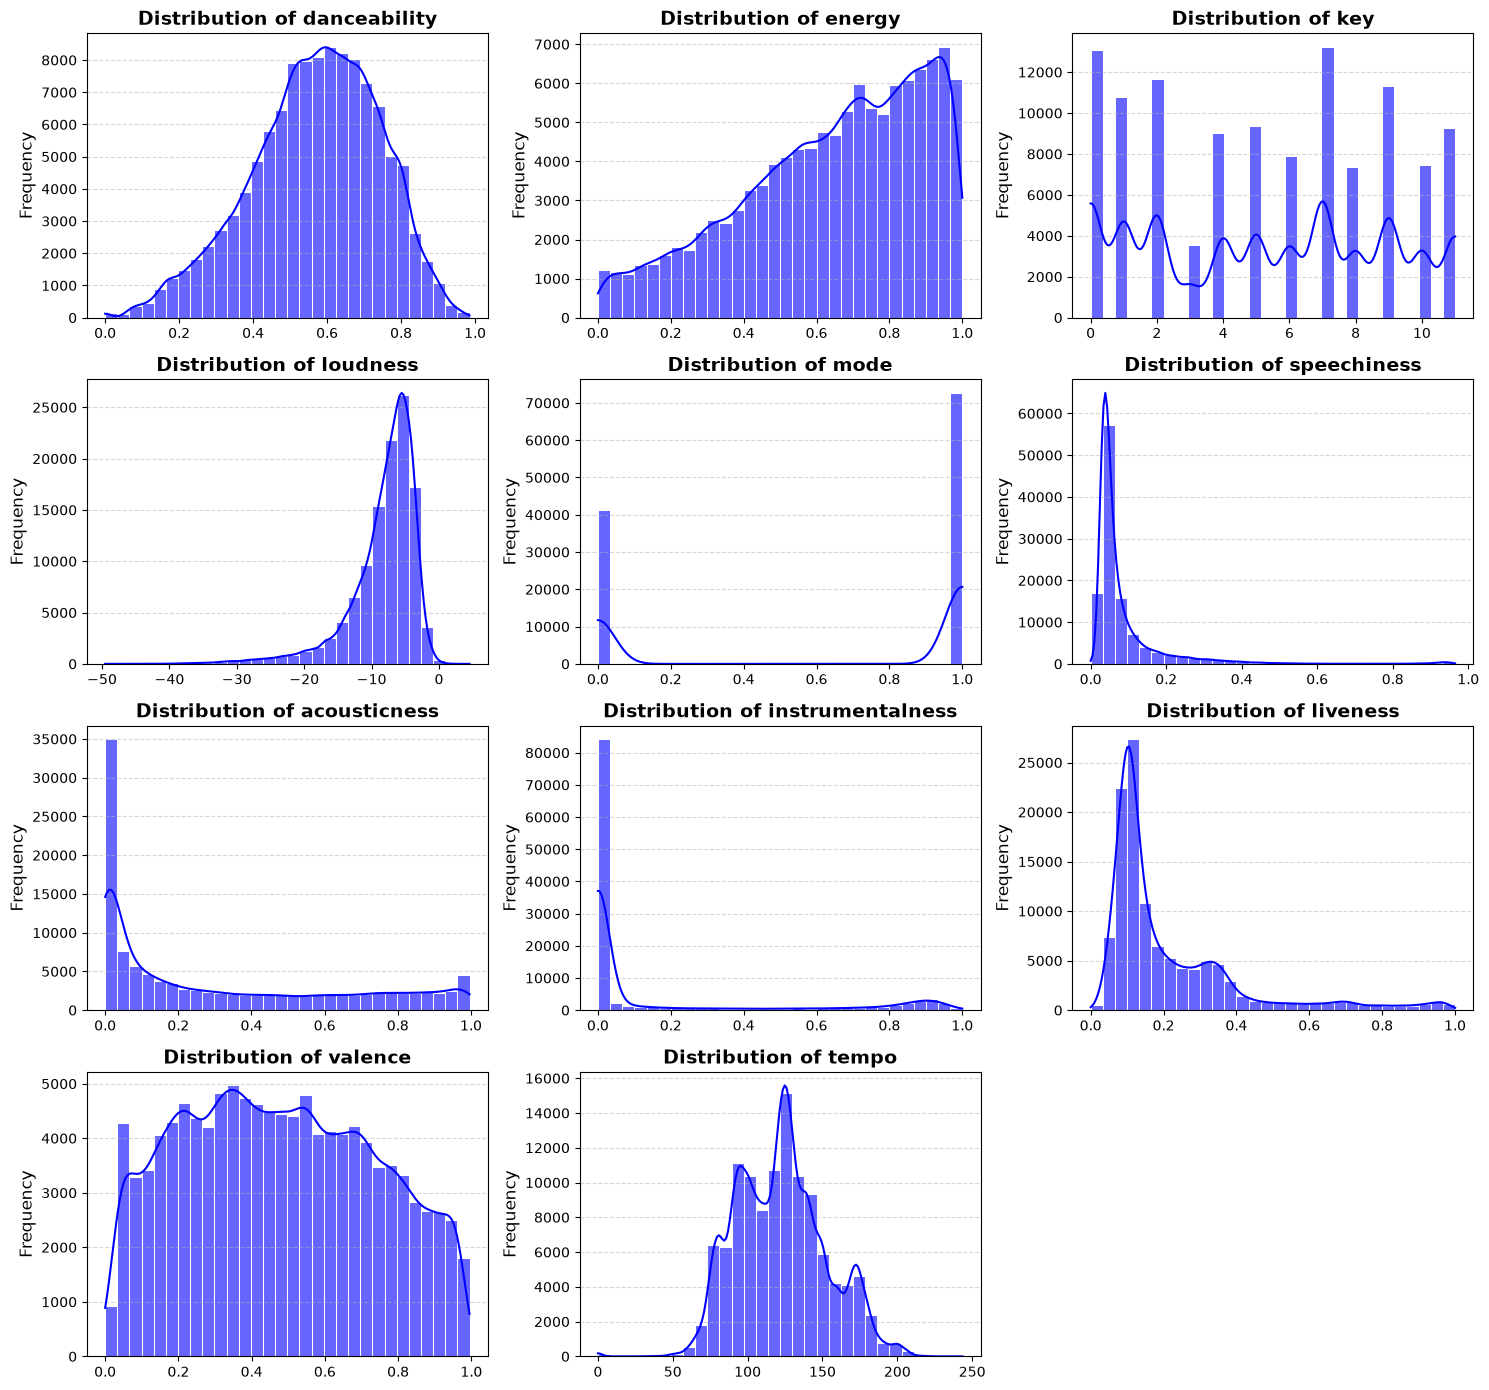

In [50]:
def plot_feature_distributions(df, feature_cols, cols, rows):
    fig, axes = plt.subplots(rows, cols, figsize = (15, rows * 3.5))
    axes = axes = axes.flatten()

    for i, col in enumerate(feature_cols):
        sns.histplot(
            df[col],
            bins = 30,
            kde = True,
            ax = axes[i],
            color = 'blue',
            edgecolor = 'white',
            alpha = 0.6
        )

        axes[i].set_title(f'Distribution of {col}', fontsize = 14, fontweight = "bold")
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Frequency", fontsize = 12)
        axes[i].grid(axis = "y", linestyle = '--', alpha = 0.5)

    for j in range(len(feature_cols), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

feature_cols = [
    'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo'
]

cols = 3
rows = math.ceil(len(feature_cols)/cols)

plot_feature_distributions(df, feature_cols, cols, rows)

In [51]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## Data Cleaning and Processing
The [dataset](https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset) shows the cleanliness and provides documentation on the column names and values, which will be used in this section

In [52]:
# https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset

print(f"Number of Rows: {len(df)}")

# drop any null rows and duplicate rows
df = df.dropna(subset=feature_cols).reset_index(drop=True)
df = df.drop_duplicates(subset=["track_id"]).reset_index(drop=True)
print(f"Number of Clean Rows: {len(df)}")

Number of Rows: 114000
Number of Clean Rows: 89741


Non-normal variables detected by normal test: (9): ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
Original danceability skewness: -0.3982754597268451
Normalized danceability skewness: -0.1474555655194503


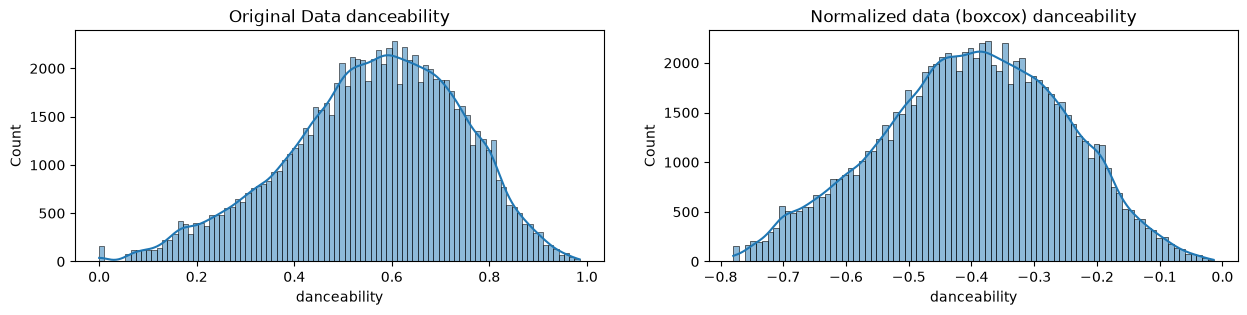

Original energy skewness: -0.5599793080080613
Normalized energy skewness: -0.3793060846962258


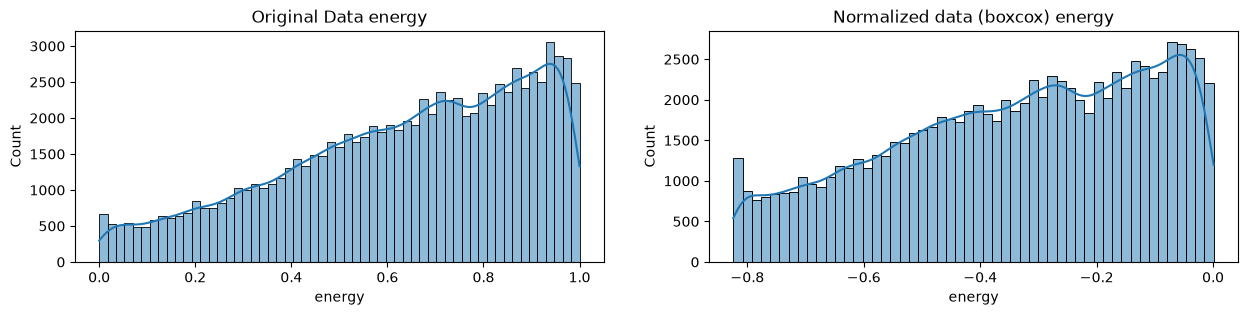

Original loudness skewness: -1.9598503531400822
Normalized loudness skewness: -0.22674956284609288


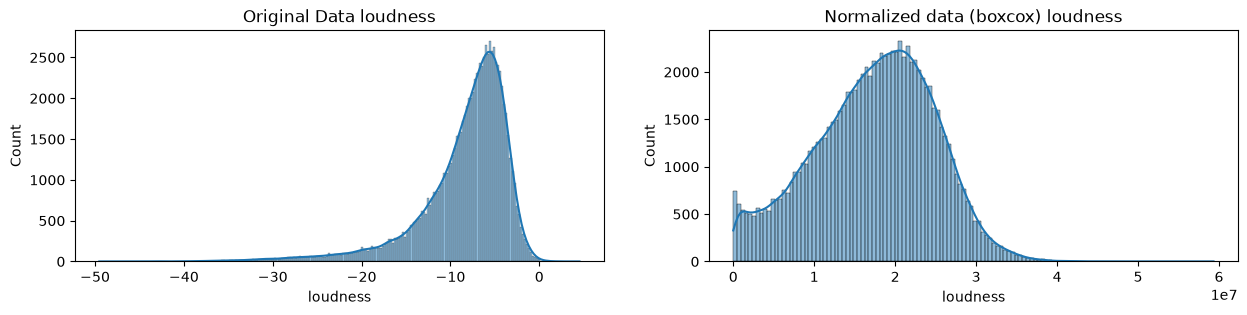

Original speechiness skewness: 4.5457873532276825
Normalized speechiness skewness: -0.28306706412032906


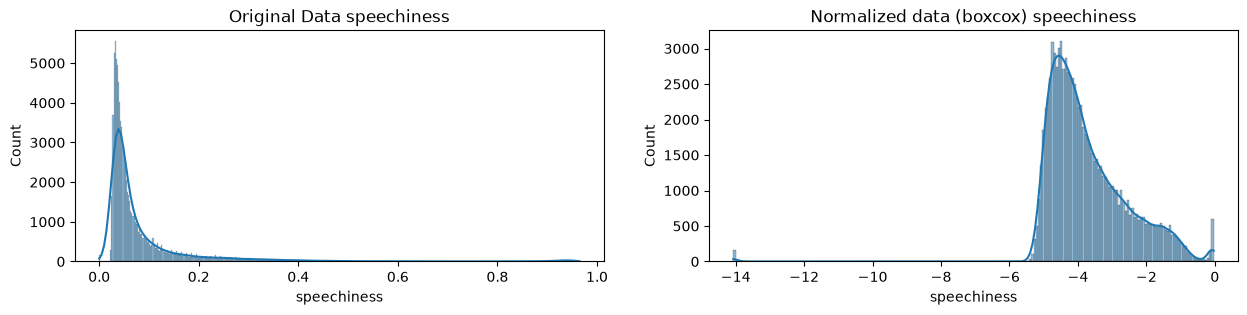

Original acousticness skewness: 0.655729744821229
Normalized acousticness skewness: -0.25946655104273797


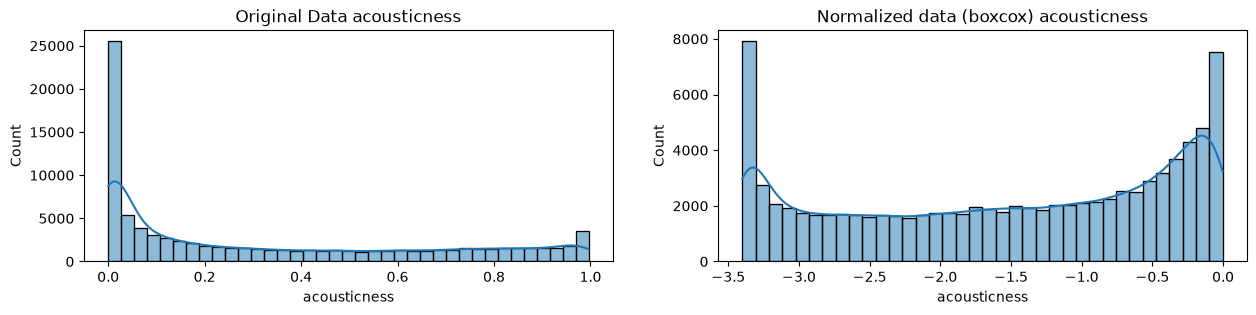

Original instrumentalness skewness: 1.5639879642133683
Normalized instrumentalness skewness: 0.6494761302666229


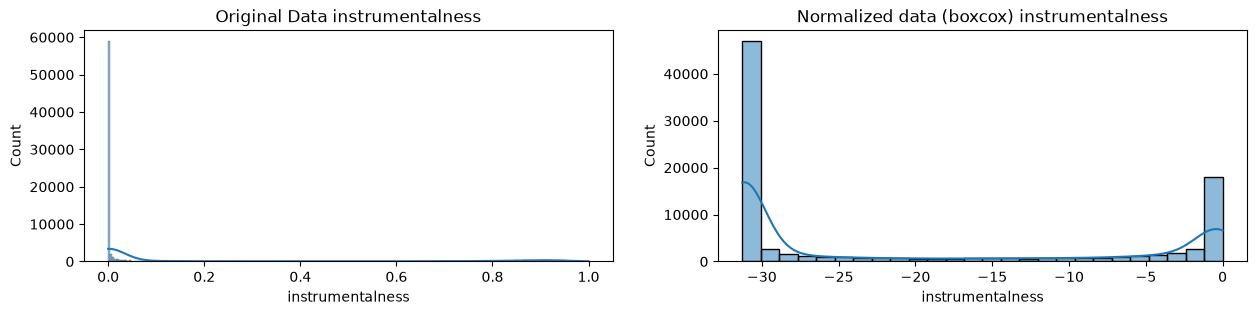

Original liveness skewness: 2.0620711269426617
Normalized liveness skewness: -0.01833049833091387


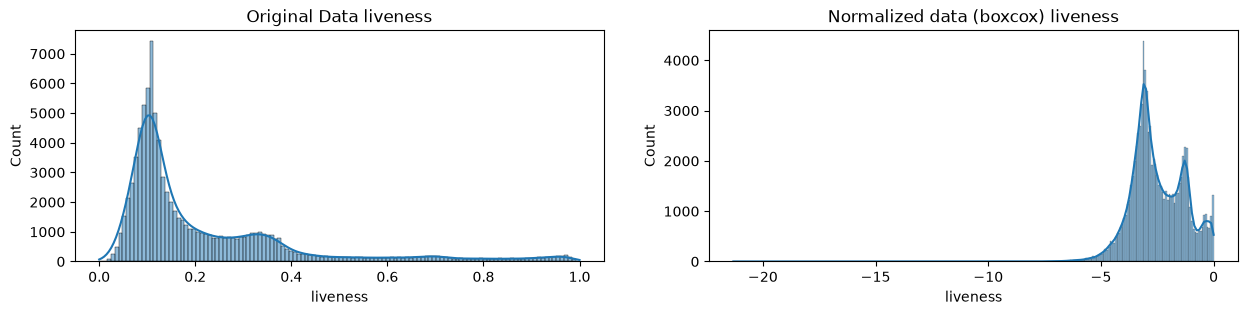

Original valence skewness: 0.12761142717808774
Normalized valence skewness: -0.20788630750265896


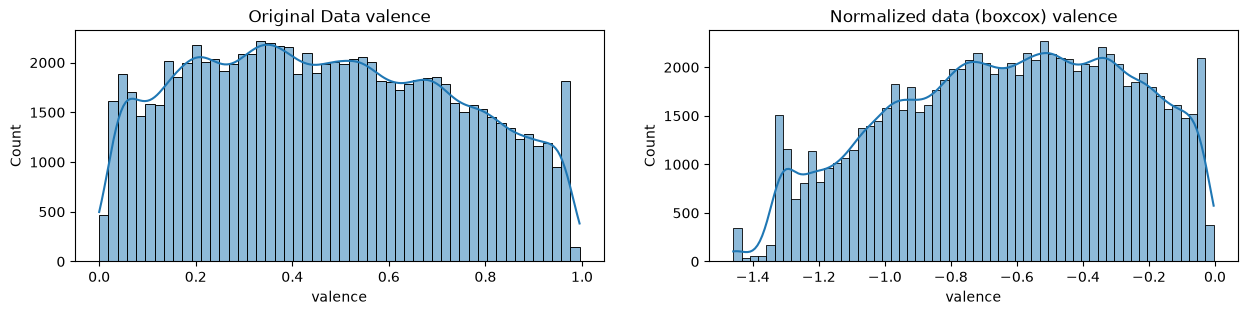

Original tempo skewness: 0.18272515728635996
Normalized tempo skewness: 0.00928136533564843


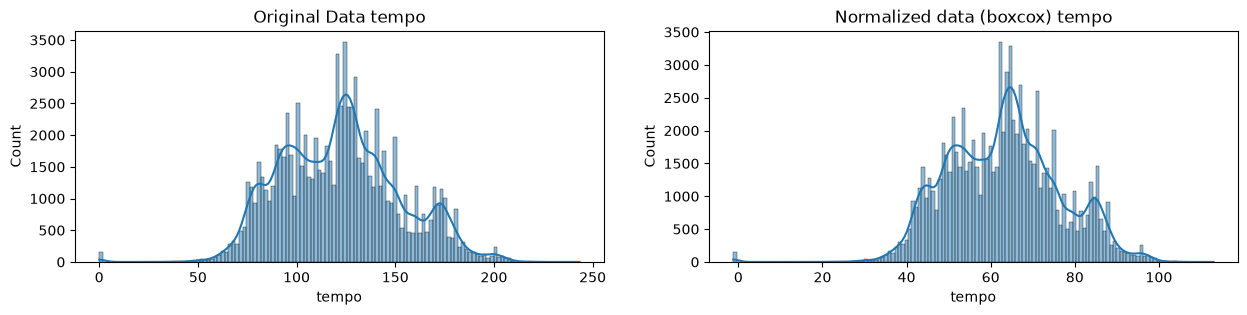

In [53]:
skewed_vars = []
for var in feature_cols:
    categorical_vars = ['key', 'mode']
    if var in categorical_vars:
        continue

    val_skew = skew(df[var])
    stat, p_val = normaltest(df[var])

    if p_val < 0.05:
        skewed_vars.append(var)

print(f"Non-normal variables detected by normal test: ({len(skewed_vars)}): {skewed_vars}")

for var in skewed_vars: 
    skewness = skew(df[var])
    print(f"Original {var} skewness: {skewness}")
    
    fig, ax=plt.subplots(1, 2, figsize=(15, 3))
    sns.histplot(df[var], ax=ax[0], kde=True, legend=False)
    ax[0].set_title(f"Original Data {var}")
    
    # boxcox cannot take 0 or negative values, and the lowest value something can be here is -0.360
    # shift all values up by 0.361, which doesn't change the distributions
    min_value = df[var].min()

    if min_value <= 0:
        shift_amount = np.abs(min_value) + 0.001 
        shifted_values = df[var] + shift_amount
    else:
        shifted_values = df[var]

    # Apply Box-Cox transformation to shifted values
    transformed_values, _ = boxcox(shifted_values)
    df[var] = transformed_values
    
    new_skewness = skew(df[var])
    print(f"Normalized {var} skewness: {new_skewness}")

    sns.histplot(df[var], ax=ax[1], kde=True, legend=False)
    ax[1].set_title(f"Normalized data (boxcox) {var}")
    plt.show()

### Column Values
As for processing though, certain audio features are scaled to between 0 and 1 so that it will not dominate distance calculations for nearest neighbors model
- `danceability`, `energy`, `speechiness`, `acousticness`, `instrumentalness`, `liveliness`, `valence` $\rightarrow$ float 0 - 11
- `key` $\rightarrow$ int 0 - 11
- `loudness` $\rightarrow$ float -49.53 - 4.53 dB
- `mode` $\rightarrow$ int 0 or 1
- `tempo` $\rightarrow$ float 0 - 243 bpm

### Tempo
According to [Krumhansl](https://cogsci.northwestern.edu/events/2016-2017-events/Krumhansl_2000.pdf), if the time between each beat is more than 1.5 seconds, then listeners have difficulty grouping sounds. As such, 40 BPM $60 / 1.5 = 40$ will be used as the bare minimum of what is considered "music". Unfortunately, this column is machine generated and Spotify's algorithm has trouble classifying BPM for all songs accurately. I will be dropping songs below 40 BPM

### Key
Treating Key as linear is not feasible because it wraps around. 0 (C) and 11 (B) are adjacent semitones (just 1 key apart on the piano), but are treated as maximally distant from one another. Although musical key definitely contributes to how music sounds, I'll be dropping it because the harmonics are less important than the other features

### Loudness
Loudness has a negative skew because decibels are a logarithmic scale. I will use percentile-based clipping for loudness

### Tempo Doubling/Halving
Some songs might have their BPMs halved while others doubled. For example, 120 BPM might be represented as 60, 120, or even 240 BPM. While I love music, I will not be listening to the 100k+ songs to clean the bpm data. I do think bpm is still important enough to keep in, despite the possible discrepancies.

### Instrumentalness, Acousticness, Speechiness, Liveliness, Energy
Instrumentalness, Acousticness, Speechiness, Liveliness are all positively skewed. Energy is negatively skewed. I will apply a transformation to each feature to each one

### Mode
Mode is binary (0 = minor, 1 = major), which can represent a large swing in distance for a nearest neighbors model. 

c:\Users\kevzj\Documents\GitHub\Spotify Stats\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Dataset ready for modeling. Feature matrix shape: (87866, 10)


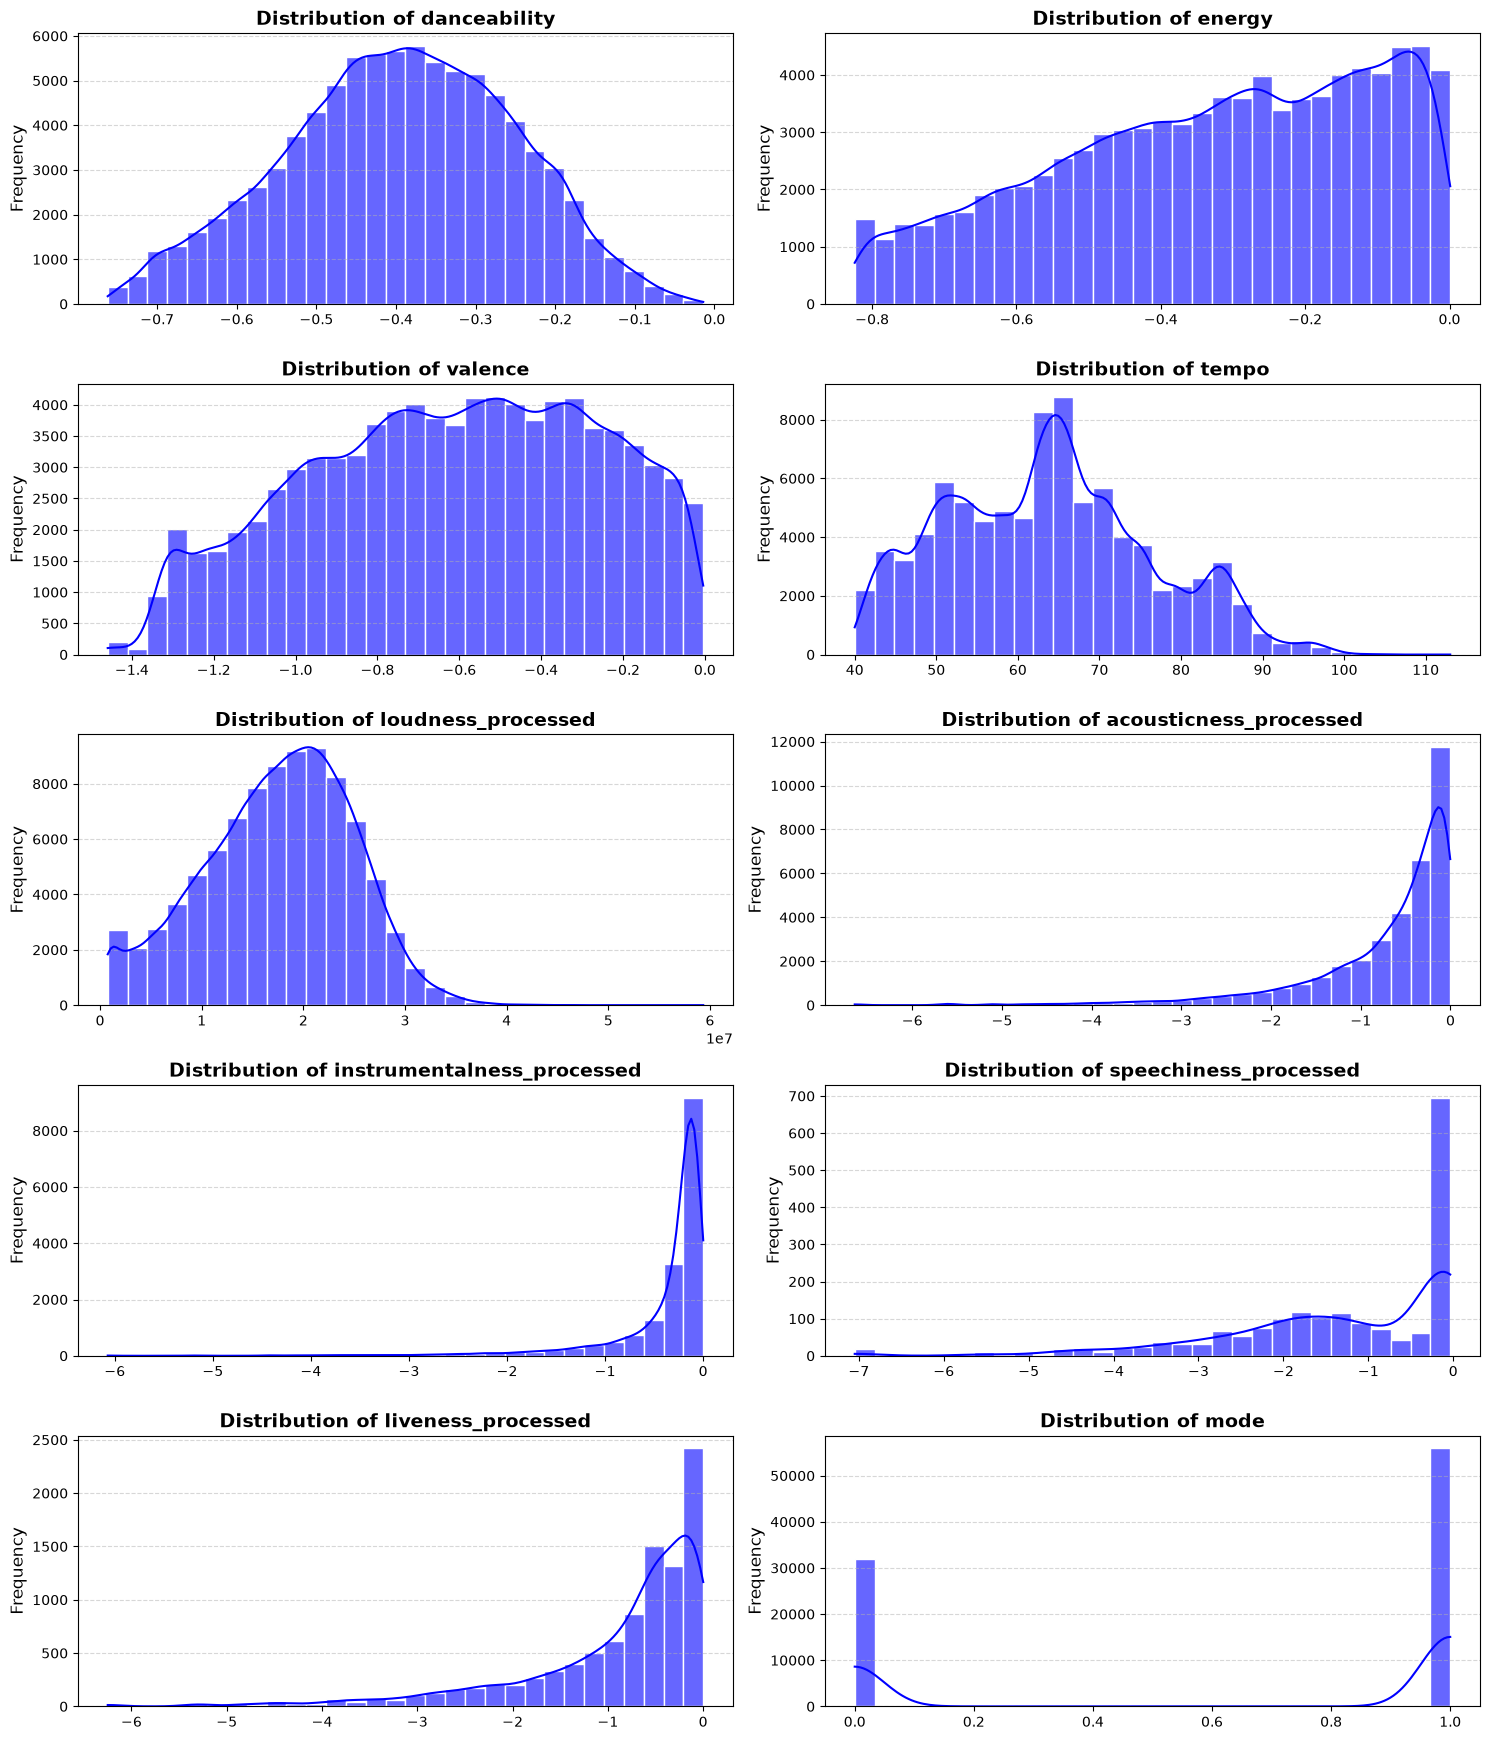

In [54]:
# Filter out songs with missing or invalid tempo
df = df[df["tempo"] > 40.0].reset_index(drop=True)

# clip loudness to the 1st percentil to avoid extreme negative compression
lower_loudness = df["loudness"].quantile(0.01)
df["loudness_processed"] = df["loudness"].clip(lower=lower_loudness)

# transform heavy right-skewed features using log1p: log(1 + x)
df["instrumentalness_processed"] = np.log1p(df["instrumentalness"])
df["speechiness_processed"] = np.log1p(df["speechiness"])
df["liveness_processed"] = np.log1p(df["liveness"])
df["acousticness_processed"] = np.log1p(df["acousticness"])

# features to use in the final model (excluding key, keeping mode with downweighted impact)
model_features = [
    "danceability",
    "energy",
    "valence",
    "tempo",
    "loudness_processed",
    "acousticness_processed",
    "instrumentalness_processed",
    "speechiness_processed",
    "liveness_processed",
    "mode",
]

# scale all selected features to [0, 1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df[model_features])

print(f"Dataset ready for modeling. Feature matrix shape: {X_scaled.shape}")

cols = 2
rows = math.ceil(len(model_features)/cols)
plot_feature_distributions(df, model_features, cols, rows)

In [55]:
nn_model = NearestNeighbors(n_neighbors=10, metric="cosine", algorithm="brute")
nn_model.fit(X_scaled)

print("Nearest Neighbors model fitted successfully!")

ValueError: Input X contains NaN.
NearestNeighbors does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values